# Disparités de santé gynécologique — Analyse descriptive
**Dataset** : TidyTuesday 2025-02-25  
**Source** : `article_dat.csv` — articles scientifiques sur les inégalités de santé en gynécologie

## 0. Imports & chargement

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from Modules.graphic_drawer import GraphicDrawer

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-02-25/article_dat.csv"
df = pd.read_csv(URL, low_memory=False)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(3)

Dimensions : 318 lignes × 65 colonnes


,pmid,doi,jabbrv,journal,year,month,day,title,abstract,keywords,...,other_gyn_onc,endo,fibroids,other_gyn_surg,fert,matmorbmort,other_preg,phys_div,other,covid
0,31764726,10.1097/AOG.0000000000003552,Obstet Gynecol,Obstetrics and gynecology,2020,4,3,Desired Sterilization Procedure at the Time of...,To evaluate whether women with Medicaid are le...,Adult; Cesarean Section; Cohort Studies; Femal...,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,31492539,10.1016/j.ygyno.2019.08.013,Gynecol Oncol,Gynecologic oncology,2019,11,5,Medicaid and Medicare payer status are associa...,To compare postoperative outcomes by primary p...,Health disparities; Medicaid; Medicare; Outcom...,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30890269,10.1016/j.ygyno.2019.03.007,Gynecol Oncol,Gynecologic oncology,2019,7,5,Identifying disparities in germline and somati...,Germline mutations occur in approximately 25% ...,"Adult; Aged; Aged, 80 and over; BRCA1 Protein;...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Publications par année

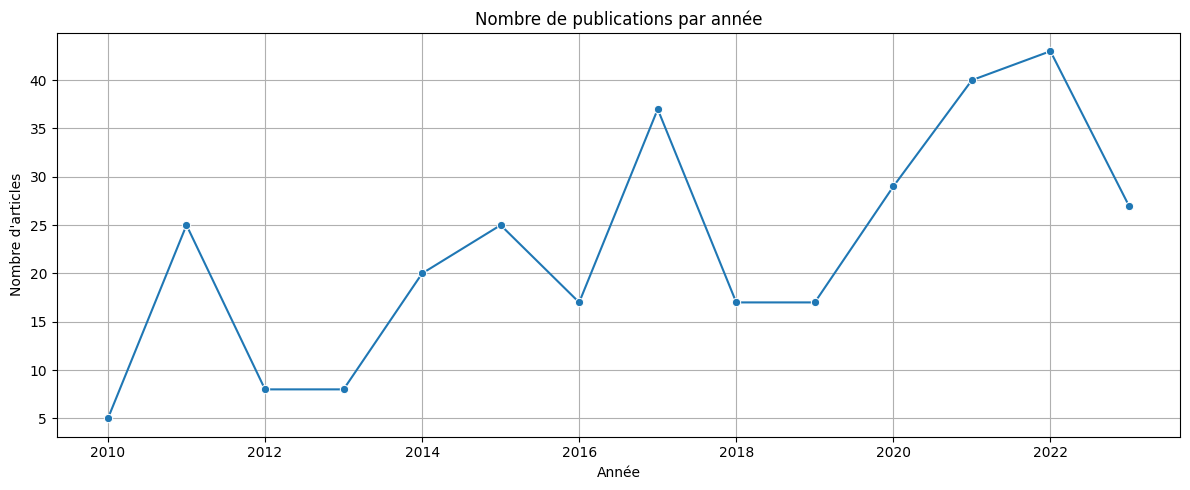

In [4]:
pubs_by_year = df.groupby("year").size().reset_index(name="Count")
pubs_by_year.columns = ["Category", "Count"]

GraphicDrawer.draw_line_plot(
    data=pubs_by_year,
    title="Nombre de publications par année",
    xlabel="Année",
    ylabel="Nombre d'articles",
    figsize=(12, 5),
)

### Analyse — Publications par année

La courbe révèle une **tendance globale à la hausse** sur la période 2010–2023, mais avec une forte volatilité d'une année à l'autre.

Quelques points marquants :

- **2010–2012** : faible volume (~5–25 articles/an), phase de démarrage du corpus ou biais de collecte sur les années les plus anciennes.
- **2017** : premier pic notable (~37 articles), coïncidant probablement avec un intérêt croissant pour les disparités raciales en santé dans le contexte post-élection américaine.
- **2018–2019** : baisse inexpliquée, qui peut refléter un délai de publication ou un biais de la base de données source.
- **2021–2022** : pic maximal (~40–43 articles), porté par l'attention suscitée par les inégalités de santé mises en lumière pendant la pandémie COVID-19.

## 2. Top 10 journaux 

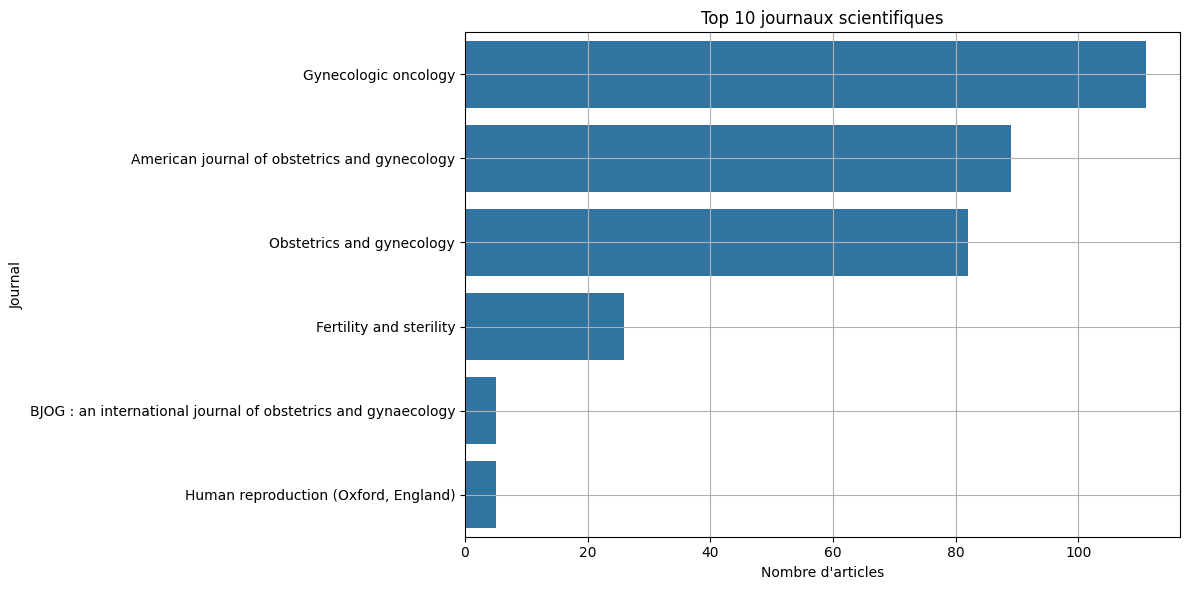

In [5]:
top_journals = (
    df["journal"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_journals.columns = ["Category", "Count"]

GraphicDrawer.draw_bar_plot(
    data=top_journals,
    top_n=10,
    title="Top 10 journaux scientifiques",
    xlabel="Nombre d'articles",
    ylabel="Journal",
    figsize=(12, 6),
)

### Analyse — Top 10 journaux

La distribution des publications est **très concentrée** : les 3 premiers journaux représentent à eux seuls la grande majorité du corpus.

- **Gynecologic Oncology** (~110 articles) domine très largement. C'est le journal de référence pour les cancers gynécologiques, ce qui reflète le poids de cette thématique dans les disparités étudiées.
- **American Journal of Obstetrics and Gynecology** (~88 articles) et **Obstetrics and Gynecology** (~82 articles) couvrent plus largement la gynécologie obstétrique, avec un intérêt pour les inégalités d'accès aux soins et la mortalité maternelle.
- **Fertility and Sterility** (~26 articles) représente le seul journal spécialisé en fertilité dans le top 10, signalant que les disparités d'accès aux traitements de l'infertilité sont aussi documentées.
- **BJOG** et **Human Reproduction** sont des journaux internationaux (européens), leur présence marginale indique que ce corpus est **très majoritairement ancré dans la littérature américaine**.

> Seuls quelques journaux spécialisés sont présents. Cela montre que ces recherches sont visibles en grande partie pour un public averti, et non dans la presse médicale généraliste.

## 3. Types d'étude 

---

La colonne `study_type` contient les types d'étude tels qu'ils ont été saisis. Par conséquent, on remarque des **incohérences orthographiques** pour une même catégorie : 
 
La cellule suivante explore d'abord les valeurs brutes, puis applique une normalisation.

In [6]:
df["study_type"].value_counts()# Exploration des valeurs brutes — on constate les doublons orthographiques
print("Valeurs brutes de study_type :")
print(df["study_type"].value_counts().to_string())

Valeurs brutes de study_type :
study_type
Retrospective cohort    130
Retrospective Cohort     82
Registry                 23
Cross-sectional          21
Cross-Sectional          20
Prospective cohort       16
Case-control              9
RCT                       8
Prospective Cohort        6


### Stratégie de normalisation

1. La valeur est mise en minuscules et sans espaces superflus.
2. On recherche un mot-clé caractéristique dans la chaîne (`"retrospective"`, `"prospective"`, etc.).

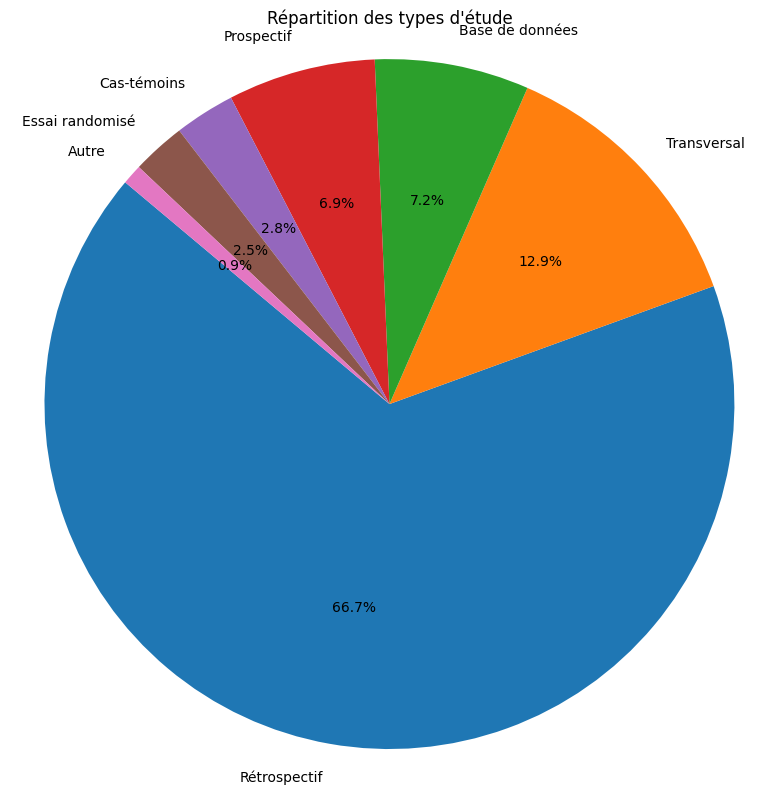

In [7]:
def normalize_study_type(val):
    if pd.isna(val):
        return "Autre"
    val = val.lower().strip()
    if "retrospective" in val:
        return "Rétrospectif"
    if "prospective" in val:
        return "Prospectif"
    if "cross" in val:
        return "Transversal"
    if "randomized" in val or "rct" in val or "trial" in val:
        return "Essai randomisé"
    if "case" in val and "control" in val:
        return "Cas-témoins"
    if "registry" in val :
        return "Base de données"
    return "Autre"

study_types = (
    df["study_type"]
    .apply(normalize_study_type)
    .value_counts()
    .to_dict()
)

GraphicDrawer.draw_pie_chart(
    data=study_types,
    top_n=8,
    title="Répartition des types d'étude",
    figsize=(8, 8),
)

### Analyse — Types d'étude

On remarque un grand **déséquilibre** :

- **Rétrospectif (66,7 %)** : deux tiers du corpus. Les études rétrospectives reposent sur des données déjà collectées (dossiers médicaux, registres) et sont moins coûteuses à mener.
- **Transversal (12,9 %)** : Une étude transversale concerne l'observation d'une population à un instant donné dans le temps.
- **Base de données (7,2 %)** : analyses de données administratives, permettant des échantillons très larges mais peu de contrôle sur les données. 
- **Prospectif (6,9 %)** : Une étude prospective est définie comme un plan de recherche qui suit un groupe d'individus au fil du temps pourtant plus robustes méthodologiquement, on remarque qu'elles sont plus rares, car coûteuses et longues.

## 4. Durée des études

---

### Calcul et nettoyage

La durée est calculée comme `study_year_end - study_year_start`.  
Quelques précautions s'imposent :

- **Durées négatives** : elles résultent d'erreurs de saisie (année de fin antérieure à l'année de début). Elles sont supprimées.
- **Durées aberrantes** : des valeurs très grandes (>100 ans) correspondent probablement à des erreurs. Elles sont également exclues pour ne pas écraser l'histogramme.


Avant nettoyage : 313 valeurs
  Durées négatives : 2
  Min / Max brut  : -2109 / 2121
Après nettoyage  : 309 valeurs conservées
  Min / Max clean : 0 / 42
  Médiane          : 5.0 ans


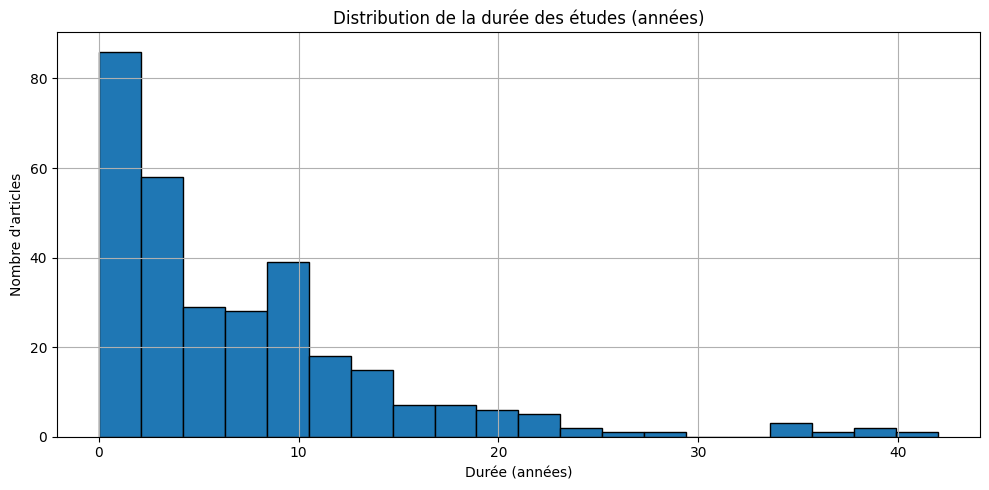

In [8]:
df["study_duration"] = df["study_year_end"] - df["study_year_start"]
duration_raw = df["study_duration"].dropna()

print(f"Avant nettoyage : {len(duration_raw)} valeurs")
print(f"  Durées négatives : {(duration_raw < 0).sum()}")
print(f"  Min / Max brut  : {duration_raw.min():.0f} / {duration_raw.max():.0f}")

# Suppression des durées négatives et des valeurs aberrantes (> 100 ans), ces valeurs rendent le graphique ilisible et sont très rares. 
duration = duration_raw[(duration_raw >= 0) & (duration_raw <= 100)]

print(f"Après nettoyage  : {len(duration)} valeurs conservées")
print(f"  Min / Max clean : {duration.min():.0f} / {duration.max():.0f}")
print(f"  Médiane          : {duration.median():.1f} ans")

GraphicDrawer.draw_histogram(
    data=duration,
    bins=20,
    title="Distribution de la durée des études (années)",
    xlabel="Durée (années)",
    ylabel="Nombre d'articles",
    figsize=(10, 5),
)

### Analyse — Distribution de la durée des études 

- **Mode à 0–2 ans** : le pic dominant (~85 articles) regroupe les études très courtes.
- **Durée médiane de 5 ans** : la moitié des études portent sur une période de 5 ans ou moins.
- **Queue à droite** : quelques études couvrent 20 à 42 ans. Ces cas sont rares.

> La durée médiane courte (5 ans) renforce l'idée que la plupart des études sont des **analyses ponctuelles**.

## 5. Durée des études

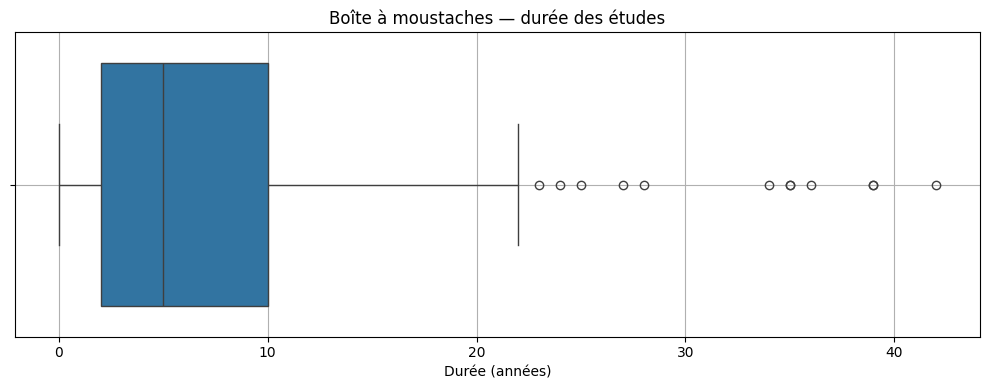

In [9]:
GraphicDrawer.draw_box_plot(
    data=duration,
    title="Boîte à moustaches — durée des études",
    xlabel="Durée (années)",
    figsize=(10, 4),
)

### Analyse — Boîte à moustaches sur la durée des études

La boîte à moustaches confirme et synthétise ce que révèle l'histogramme :

- **Q1 ≈ 2 ans, médiane ≈ 5 ans, Q3 ≈ 10 ans** : 50 % des études ont une durée comprise entre 2 et 10 ans.
- **Moustache droite** s'étend jusqu'à ~23 ans (valeur maximale non aberrante).
- **Valeurs atypiques (outliers)** : une dizaine de points dispersés entre 23 et 42 ans, correspondant aux études exceptionnellement longues.

## 6. Domaines de recherche 

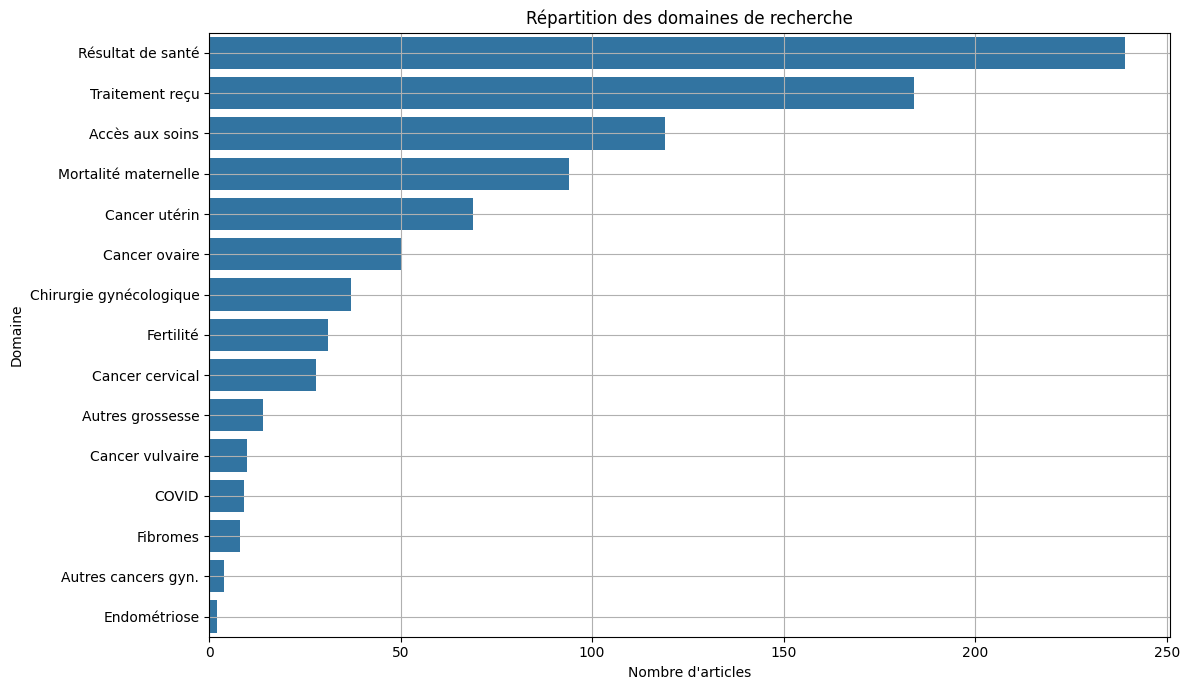

In [10]:
domain_map = {
    "cancer_ovarian":      "Cancer ovaire",
    "cancer_uterine":      "Cancer utérin",
    "cancer_cervical":     "Cancer cervical",
    "cancer_vulvar":       "Cancer vulvaire",
    "endo":                "Endométriose",
    "fibroids":            "Fibromes",
    "fert":                "Fertilité",
    "matmorbmort":         "Mortalité maternelle",
    "other_preg":          "Autres grossesse",
    "other_gyn_surg":      "Chirurgie gynécologique",
    "other_gyn_onc":       "Autres cancers gyn.",
    "access_to_care":      "Accès aux soins",
    "treatment_received":  "Traitement reçu",
    "health_outcome":      "Résultat de santé",
    "covid":               "COVID",
}

domain_counts = {
    label: int(df[col].sum())
    for col, label in domain_map.items()
    if col in df.columns
}
domain_df = (
    pd.Series(domain_counts)
    .sort_values(ascending=False)
    .reset_index()
)
domain_df.columns = ["Category", "Count"]

GraphicDrawer.draw_bar_plot(
    data=domain_df,
    top_n=15,
    title="Répartition des domaines de recherche",
    xlabel="Nombre d'articles",
    ylabel="Domaine",
    figsize=(12, 7),
)

### Analyse — Répartition des domaines de recherche

Ce graphique est l'un des plus révélateurs du corpus, car il montre **ce que les chercheurs choisissent d'étudier** en matière de disparités de santé gynécologique.

**Trois domaines transversaux dominent largement** :
- **Résultat de santé (~240 articles)** : c'est le cadre analytique le plus fréquent — on mesure si les patientes d'un groupe racial ont de moins bons résultats (survie, complications, etc.).
- **Traitement reçu (~185 articles)** : on compare les traitements effectivement dispensés selon l'origine ethnique (chirurgie, chimiothérapie, hormonothérapie...).
- **Accès aux soins (~120 articles)** : moins fréquent mais important, il interroge les barrières en amont (assurance, géographie, ...)

**Parmi les pathologies spécifiques** :
- **Mortalité maternelle (~95 articles)** est le domaine pathologique le plus étudié, reflétant l'alerte nationale aux États-Unis sur les taux de mortalité maternelle disproportionnés chez les femmes noires.

## 7. Groupes raciaux les plus étudiés

### Structure des données

Le dataset utilise une structure tabulaire, chaque article peut mentionner jusqu'à 8 groupes raciaux différents, répartis sur 8 colonnes séparées (`race1` à `race8`).

pd.concat([df[c] for c in race_cols])` empile toutes les colonnes verticalement en une seule `Series`,  
puis `value_counts()` compte chaque groupe sur l'ensemble des 8 colonnes.

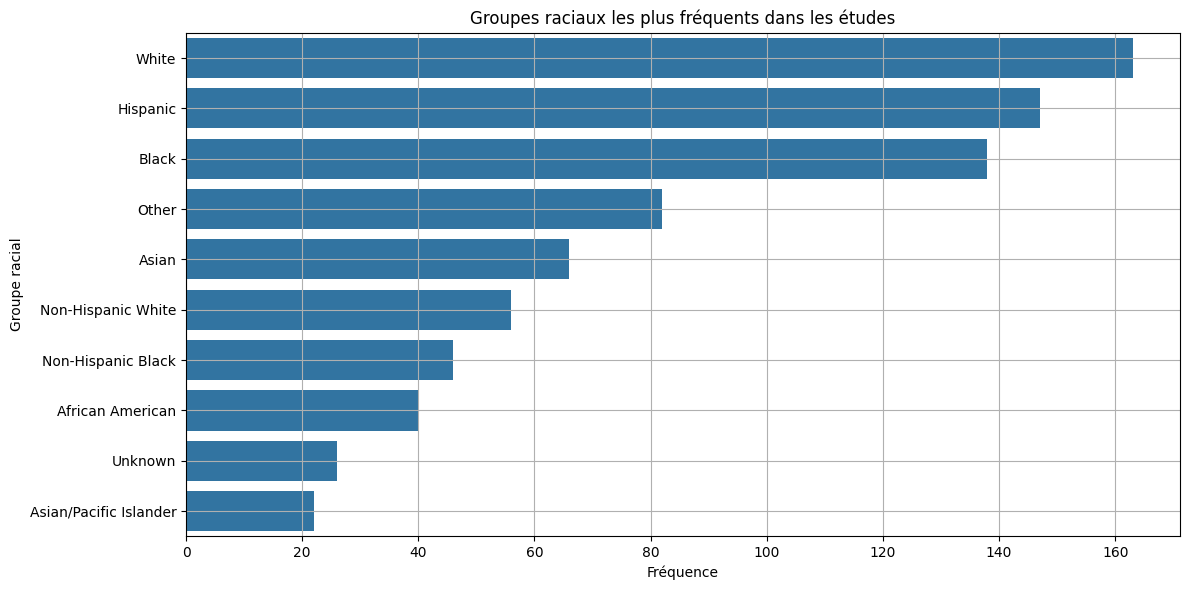

In [12]:
race_cols = [c for c in df.columns if c.startswith("race") and not c.endswith("_ss")]
race_counts = (
    pd.concat([df[c] for c in race_cols])
    .dropna()
    .value_counts()
    .reset_index()
)
race_counts.columns = ["Category", "Count"]

GraphicDrawer.draw_bar_plot(
    data=race_counts,
    top_n=10,
    title="Groupes raciaux les plus fréquents dans les études",
    xlabel="Fréquence",
    ylabel="Groupe racial",
    figsize=(12, 6),
)

### Analyse — Groupes raciaux les plus étudiés

- **White (~162)** est le groupe le plus fréquemment mentionné, souvent comme **groupe de référence** dans les comparaisons statistiques.
- **Hispanic (~147)** et **Black (~138)** sont très proches, reflétant l'attention portée aux deux minorités raciales les plus documentées en santé gynécologique américaine.
- **Non-Hispanic White (~55)** et **Non-Hispanic Black (~45)** apparaissent séparément de `White` et `Black`, illustrant l'incohérence des nomenclatures entre études (certaines distinguent l'origine hispanique, d'autres non).
- **Asian/Pacific Islander (~22)** et **Unknown (~26)** : faible représentation des populations asiatiques, et présence non négligeable de données non renseignées.

> La fragmentation des labels raciaux reflète l'absence de standards uniformes dans la littérature médicale américaine. Cette hétérogénéité limite les analyses et la comparabilité des résultats entre études.